# Network Intrusion Detection System - Explore & Clean `KDDTrain+.txt`

This notebook takes the raw `KDDTrain+.txt` file and turns it into a clean `cleanTrain_data.csv` dataset. This cleaned file will be used to train the **IBM watsonx.ai AutoAI** model.

Steps in this notebook:
1. Load the raw data and assign proper column names
2. Explore: shape, dtypes, class balance, missing values, duplicates
3. Group the 23 raw attack labels into the 5 categories the project needs: `normal, DoS, Probe, R2L, U2R`
4. Encode the categorical columns (`protocol_type`, `service`, `flag`)
5. Drop useless columns (the KDD `difficulty` score, constant columns)
6. Save `cleanTrain_data.csv`

# Step 1: Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import json

pd.set_option('display.max_columns', 50)


In [3]:
df_0 = pd.read_csv("KDDTrain+.txt")
df = df_0.copy()
print("Shape:", df.shape)
df.head()

Shape: (125972, 43)


,0,tcp,ftp_data,SF,491,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.10,0.11,0.12,0.13,0.14,0.15,0.16,0.18,2,2.1,0.00,0.00.1,0.00.2,0.00.3,1.00,0.00.4,0.00.5,150,25,0.17,0.03,0.17.1,0.00.6,0.00.7,0.00.8,0.05,0.00.9,normal,20
0,0,udp,other,SF,146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,1,0.0,0.0,0.0,0.0,0.08,0.15,0.00,255,1,0.00,0.60,0.88,0.00,0.00,0.00,0.0,0.00,normal,15
1,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,123,6,1.0,1.0,0.0,0.0,0.05,0.07,0.00,255,26,0.10,0.05,0.00,0.00,1.00,1.00,0.0,0.00,neptune,19
2,0,tcp,http,SF,232,8153,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,5,5,0.2,0.2,0.0,0.0,1.00,0.00,0.00,30,255,1.00,0.00,0.03,0.04,0.03,0.01,0.0,0.01,normal,21
3,0,tcp,http,SF,199,420,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,30,32,0.0,0.0,0.0,0.0,1.00,0.00,0.09,255,255,1.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,normal,21
4,0,tcp,private,REJ,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,121,19,0.0,0.0,1.0,1.0,0.16,0.06,0.00,255,19,0.07,0.07,0.00,0.00,0.00,0.00,1.0,1.00,neptune,21


# Step 2: Set column names

`KDDTrain+.txt` has **no header row**. We don't have the names of the features from the given dataset so we name the columns from : https://www.kaggle.com/code/timgoodfellow/nsl-kdd-explorations

In [4]:
columns = [
    "duration",
    "protocol_type",
    "service",
    "flag",
    "src_bytes",
    "dst_bytes",
    "land",
    "wrong_fragment",
    "urgent",
    "hot",
    "num_failed_logins",
    "logged_in",
    "num_compromised",
    "root_shell",
    "su_attempted",
    "num_root",
    "num_file_creations",
    "num_shells",
    "num_access_files",
    "num_outbound_cmds",
    "is_host_login",
    "is_guest_login",
    "count",
    "srv_count",
    "serror_rate",
    "srv_serror_rate",
    "rerror_rate",
    "srv_rerror_rate",
    "same_srv_rate",
    "diff_srv_rate",
    "srv_diff_host_rate",
    "dst_host_count",
    "dst_host_srv_count",
    "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate",
    "dst_host_srv_serror_rate",
    "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate",
    "label",
    "difficulty"]

df.columns = columns
df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,udp,other,SF,146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,1,0.0,0.0,0.0,0.0,0.08,0.15,0.00,255,1,0.00,0.60,0.88,0.00,0.00,0.00,0.0,0.00,normal,15
1,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,123,6,1.0,1.0,0.0,0.0,0.05,0.07,0.00,255,26,0.10,0.05,0.00,0.00,1.00,1.00,0.0,0.00,neptune,19
2,0,tcp,http,SF,232,8153,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,5,5,0.2,0.2,0.0,0.0,1.00,0.00,0.00,30,255,1.00,0.00,0.03,0.04,0.03,0.01,0.0,0.01,normal,21
3,0,tcp,http,SF,199,420,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,30,32,0.0,0.0,0.0,0.0,1.00,0.00,0.09,255,255,1.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,normal,21
4,0,tcp,private,REJ,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,121,19,0.0,0.0,1.0,1.0,0.16,0.06,0.00,255,19,0.07,0.07,0.00,0.00,0.00,0.00,1.0,1.00,neptune,21


# Step 3: Data Exploration and Cleaning

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125972 entries, 0 to 125971
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125972 non-null  int64  
 1   protocol_type                125972 non-null  object 
 2   service                      125972 non-null  object 
 3   flag                         125972 non-null  object 
 4   src_bytes                    125972 non-null  int64  
 5   dst_bytes                    125972 non-null  int64  
 6   land                         125972 non-null  int64  
 7   wrong_fragment               125972 non-null  int64  
 8   urgent                       125972 non-null  int64  
 9   hot                          125972 non-null  int64  
 10  num_failed_logins            125972 non-null  int64  
 11  logged_in                    125972 non-null  int64  
 12  num_compromised              125972 non-null  int64  
 13 

In [7]:
# Missing values
print("Missing values per column:")
df.isnull().sum()

Missing values per column:


duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_rate                  0
srv_diff_h

In [8]:
# Duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [9]:
# Raw label distribution (23 specific attack names + normal)
total_labels = df['label'].nunique()
print(f"\n{total_labels} attack labels")
df['label'].value_counts()


23 attack labels


label
normal             67342
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64

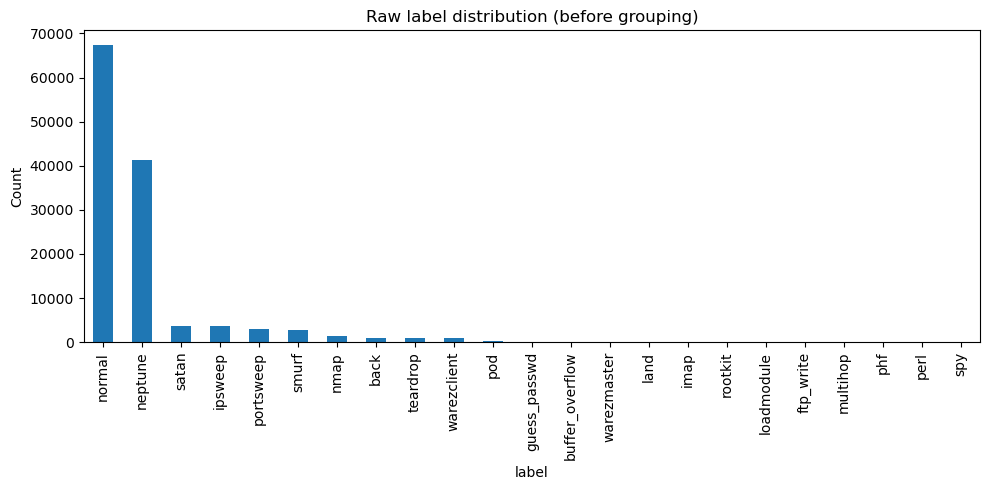

In [10]:
plt.figure(figsize=(10,5))
df['label'].value_counts().plot(kind='bar')
plt.title("Raw label distribution (before grouping)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Step 4: Group the 23 attack labels into 5 categories

The problem statement asks for **5 classes**:
`normal, DoS, Probe, R2L, U2R`. `KDDTrain+.text` raw `label` column has 23 specific attack
names, so we map every raw name to its category using the standard NSL-KDD mapping.

In [5]:
attack_mapping = {
    'normal': 'normal',

    # DoS - Denial of Service
    'back': 'DoS', 'land': 'DoS', 'neptune': 'DoS', 'pod': 'DoS',
    'smurf': 'DoS', 'teardrop': 'DoS', 'apache2': 'DoS', 'udpstorm': 'DoS',
    'processtable': 'DoS', 'mailbomb': 'DoS',

    # Probe - surveillance/scanning
    'ipsweep': 'Probe', 'nmap': 'Probe', 'portsweep': 'Probe', 'satan': 'Probe',
    'mscan': 'Probe', 'saint': 'Probe',

    # R2L - Remote to Local
    'ftp_write': 'R2L', 'guess_passwd': 'R2L', 'imap': 'R2L', 'multihop': 'R2L',
    'phf': 'R2L', 'spy': 'R2L', 'warezclient': 'R2L', 'warezmaster': 'R2L',
    'named': 'R2L', 'sendmail': 'R2L', 'snmpgetattack': 'R2L', 'snmpguess': 'R2L',
    'worm': 'R2L', 'xlock': 'R2L', 'xsnoop': 'R2L', 'httptunnel': 'R2L',

    # U2R - User to Root
    'buffer_overflow': 'U2R', 'loadmodule': 'U2R', 'perl': 'U2R', 'rootkit': 'U2R',
    'ps': 'U2R', 'sqlattack': 'U2R', 'xterm': 'U2R'
}

df['attack_category'] = df['label'].map(attack_mapping)

# make sure nothing was left unmapped
unmapped = df[df['attack_category'].isna()]['label'].unique()
print("Unmapped raw labels (should be empty):", unmapped)

Unmapped raw labels (should be empty): []


In [12]:
df['attack_category'].value_counts()

attack_category
normal    67342
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64

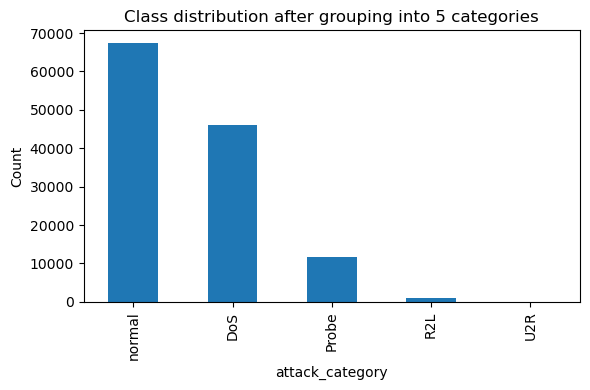

In [13]:
plt.figure(figsize=(6,4))
df['attack_category'].value_counts().plot(kind='bar')
plt.title("Class distribution after grouping into 5 categories")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Step 5: Drop columns we don't need
- `label`: the original 23-class column replaced by `attack_category`.
- `difficulty`: a KDD-specific difficulty score, not a real traffic feature (not useful for the model).
- Any **constant column** (same value in every row) adds no information, so we drop those too.

In [6]:
df_clean = df.drop(columns=['label', 'difficulty'])

# Detect and drop constant columns automatically
constant_cols = [c for c in df_clean.columns if df_clean[c].nunique() == 1]
print("Constant columns being dropped:", constant_cols)
df_clean = df_clean.drop(columns=constant_cols)

print("Shape after dropping columns:", df_clean.shape)

Constant columns being dropped: ['num_outbound_cmds']
Shape after dropping columns: (125972, 41)


# Step 6: Encode the categorical columns

`protocol_type`, `service`, and `flag` are text categories. We label-encode them
(turn each category into a number) so every column is numeric before AutoAI training.

We **save the encoders** (`label_encoders.json`) so our Streamlit app can
apply the exact same encoding to whatever the user picks in the dropdowns. The
dropdown options in the app must come from these same category lists, and the
numbers sent to the model must match this mapping.

In [7]:
categorical_cols = ['protocol_type', 'service', 'flag']
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col])
    encoders[col] = {label: int(code) for code, label in enumerate(le.classes_)}

# Save the encoders so the Streamlit app can reuse the exact same mapping later
with open('label_encoders.json', 'w') as f:
    json.dump(encoders, f, indent=2)

print("Saved label_encoders.json")
print(json.dumps(encoders['protocol_type'], indent=2))

Saved label_encoders.json
{
  "icmp": 0,
  "tcp": 1,
  "udp": 2
}


# Step 7: Final checks before export

In [8]:
print("Duplicate rows after cleaning:", df_clean.duplicated().sum())
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print("Shape after dropping duplicate rows:", df_clean.shape)

Duplicate rows after cleaning: 9
Shape after dropping duplicate rows: (125963, 41)


In [17]:
df_clean.describe()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
count,125963.000000,125963.000000,125963.000000,125963.000000,1.259630e+05,1.259630e+05,125963.000000,125963.000000,125963.000000,125963.000000,125963.000000,125963.000000,125963.000000,125963.000000,125963.000000,125963.000000,125963.000000,125963.000000,125963.000000,125963.000000,125963.000000,125963.000000,125963.000000,125963.000000,125963.000000,125963.000000,125963.000000,125963.000000,125963.000000,125963.000000,125963.000000,125963.000000,125963.000000,125963.000000,125963.000000,125963.000000,125963.000000,125963.000000,125963.000000,125963.000000
mean,287.167446,1.053278,31.227749,6.979835,4.557036e+04,1.978068e+04,0.000198,0.022689,0.000111,0.204425,0.001223,0.395767,0.279272,0.001342,0.001103,0.302216,0.012670,0.000413,0.004096,0.000008,0.009423,84.114137,27.739590,0.284507,0.282508,0.119968,0.121193,0.660901,0.063058,0.097306,182.162071,115.661845,0.521210,0.082957,0.148318,0.032545,0.284475,0.278507,0.118841,0.120249
std,2604.617436,0.426544,16.346480,2.689411,5.870564e+06,4.021429e+06,0.014087,0.253540,0.014367,2.150053,0.045241,0.489017,23.942992,0.036604,0.045156,24.400586,0.483954,0.022182,0.099373,0.002818,0.096616,114.510770,72.638379,0.446466,0.447033,0.320446,0.323658,0.439630,0.180321,0.259802,99.198421,110.702671,0.448948,0.188928,0.308926,0.112568,0.444794,0.445680,0.306568,0.319470
min,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,20.000000,5.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.090000,0.000000,0.000000,82.000000,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,1.000000,24.000000,9.000000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,8.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,255.000000,63.000000,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,1.000000,49.000000,9.000000,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,143.000000,18.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.060000,0.000000,255.000000,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000
max,42908.000000,2.000000,69.000000,10.000000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,1.000000,2.000000,7468.000000,43.000000,2.000000,9.000000,1.000000,1.000000,511.000000,511.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,255.000000,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


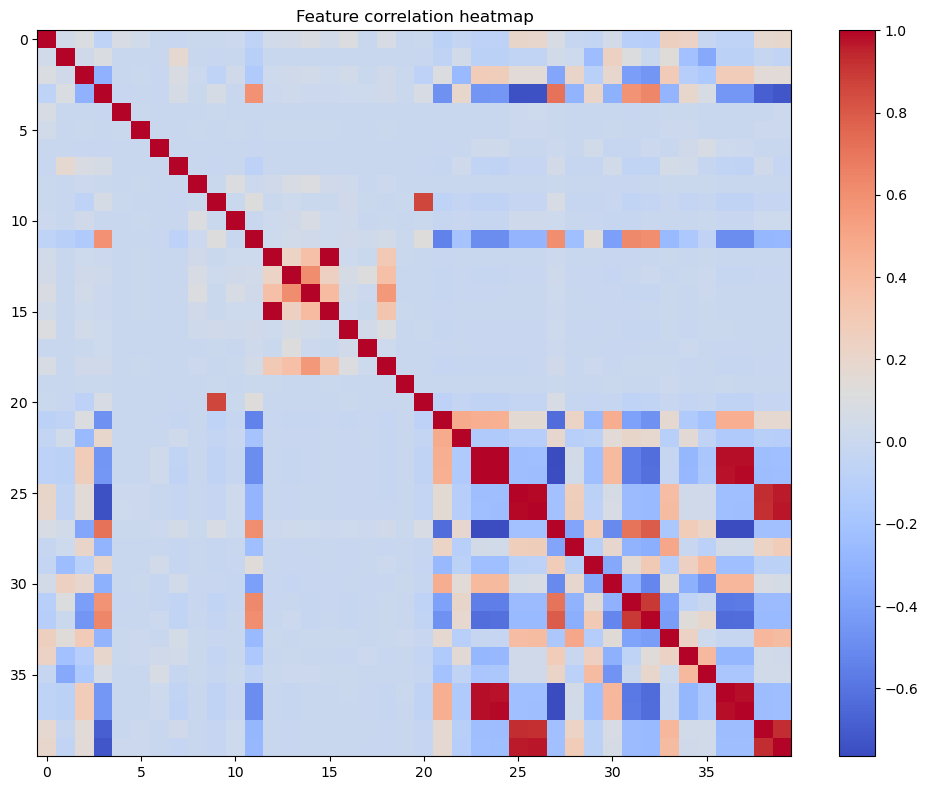

In [9]:
plt.figure(figsize=(8,8))
plt.imshow(df_clean.corr(numeric_only=True), cmap='coolwarm', aspect='auto')
plt.colorbar()
plt.title("Feature correlation heatmap")
plt.tight_layout()
plt.show()

# Step 8: Save `cleanTrain_data.csv`

In [19]:
df_clean.to_csv('cleanTrain_data.csv', index=False)
print("Saved cleaned_data.csv with shape:", df_clean.shape)
df_clean.head()

Saved cleaned_data.csv with shape: (125963, 41)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack_category
0,0,2,44,9,146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,1,0.0,0.0,0.0,0.0,0.08,0.15,0.00,255,1,0.00,0.60,0.88,0.00,0.00,0.00,0.0,0.00,normal
1,0,1,49,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,123,6,1.0,1.0,0.0,0.0,0.05,0.07,0.00,255,26,0.10,0.05,0.00,0.00,1.00,1.00,0.0,0.00,DoS
2,0,1,24,9,232,8153,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,5,5,0.2,0.2,0.0,0.0,1.00,0.00,0.00,30,255,1.00,0.00,0.03,0.04,0.03,0.01,0.0,0.01,normal
3,0,1,24,9,199,420,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,30,32,0.0,0.0,0.0,0.0,1.00,0.00,0.09,255,255,1.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,normal
4,0,1,49,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,121,19,0.0,0.0,1.0,1.0,0.16,0.06,0.00,255,19,0.07,0.07,0.00,0.00,0.00,0.00,1.0,1.00,DoS
